# Оценка справедливой стоимости инструментов

Модуль для расчета [`pricing.py`](pricing.py).

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pricing as P

plt.rcParams['figure.dpi'] = 110

md = pd.read_csv('data/data_clean.csv', parse_dates=['DATE']).set_index('DATE').sort_index()
cf = pd.read_csv('data/ofz_cashflows.csv', parse_dates=['date'])
cf['ofz_id'] = cf['secid'].map(P.OFZ_ISIN_TO_ID)
rf = pd.read_csv('risk_factors_output/risk_factors.csv', parse_dates=['DATE']).set_index('DATE').sort_index()
spca = {
    'loadings': pd.read_csv('risk_factors_output/stock_pca_loadings.csv', index_col=0),
    'pcs': pd.read_csv('risk_factors_output/stock_pcs.csv', parse_dates=['DATE']).set_index('DATE').sort_index(),
}

print(f'рыночные данные: {md.shape[0]} дней, {md.index[0].date()} → {md.index[-1].date()}')
print(f'факторы:         {rf.shape[0]} дней')
print(f'выпуски ОФЗ:     {sorted(cf["ofz_id"].unique())}')
ev = spca['loadings'].loc['_explained_var_ratio', ['PC1', 'PC2', 'PC3']]
print(f'доля дисперсии STOCK_PC1-3: {(ev.values*100).round(1)} (cum={ev.sum()*100:.1f}%)')

рыночные данные: 1271 дней, 2021-01-04 → 2025-12-30
факторы:         1270 дней
выпуски ОФЗ:     ['OFZ_26212', 'OFZ_26218', 'OFZ_26219', 'OFZ_26221', 'OFZ_26230']
доля дисперсии STOCK_PC1-3: [62.4  6.7  5.5] (cum=74.6%)


## 1. Конвенция дисконтирования и кривая ZCYC

Кривая бескупонной доходности ЦБ РФ берётся напрямую из `data_clean.csv`. 

Конвенция (фиксирована в `discount_factors`):

- ZCYC — annually compounded
- $DF(\tau)=\frac{1}{(1+z(\tau))^{\tau}}$

 срок, лет  ставка, %
      0.25      12.10
      0.50      12.50
      0.75      12.84
      1.00      13.14
      2.00      13.92
      3.00      14.30
      5.00      14.58
      7.00      14.59
     10.00      14.44
     15.00      14.11
     20.00      13.91
     30.00      13.79


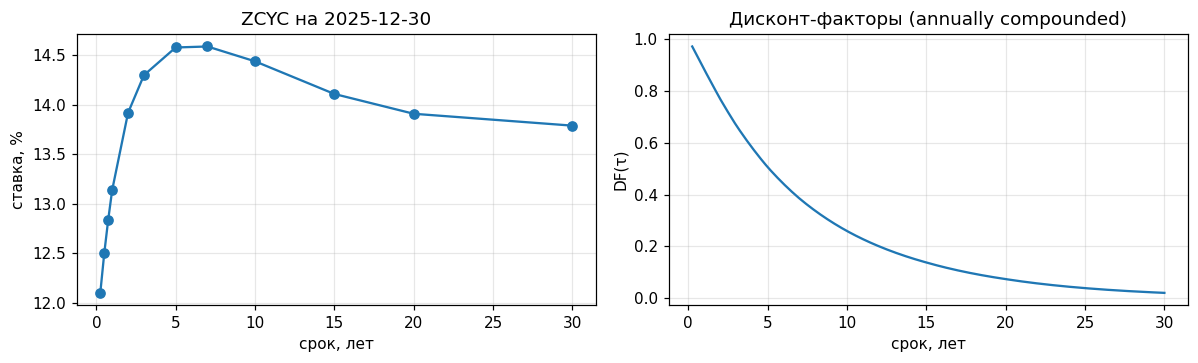

In [11]:
asof = pd.Timestamp('2025-12-30')
curve = P.get_rate_curve(asof, market_data=md)
print(pd.DataFrame({'срок, лет': P.TENORS,
                    'ставка, %': [round(curve[t], 2) for t in P.TENORS]}).to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(P.TENORS, [curve[t] for t in P.TENORS], 'o-')
axes[0].set_xlabel('срок, лет'); axes[0].set_ylabel('ставка, %')
axes[0].set_title(f'ZCYC на {asof.date()}'); axes[0].grid(alpha=0.3)
taus = np.linspace(0.25, 30, 200)
axes[1].plot(taus, P.discount_factors(curve, taus), '-')
axes[1].set_xlabel('срок, лет'); axes[1].set_ylabel('DF(τ)')
axes[1].set_title('Дисконт-факторы (annually compounded)'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Выводы

- Кривая ЦБ дана в формате annually compounded. 
- Форма кривой на конец 2025 года: короткие ставки (до года) ниже среднесрочных (3–7 лет) — это инверсия, признак жёсткой денежно-кредитной политики. Дисконт-факторы на 30 лет падают примерно до 0.12 — то есть 1 рубль через 30 лет сегодня стоит около 12 копеек.

## 2. Pricing облигаций (ОФЗ-ПД)

Грязная цена — полная стоимость облигации, включая накопленный купон. Считаем через дисконтирование всех будущих платежей.

$P^{dirty} = \sum_i CF_i \cdot (1+z(\tau_i))^{-\tau_i}$

Чистая цена — грязная цена минус накопленный купон (НКД), это рыночная котировка.

$P^{clean} = P^{dirty} - NKD$.

$NKD = \frac{\text{дней от прошлого купона до }t_0}{\text{длина купонного периода}} \cdot \text{купон текущего периода}$

In [12]:
curve = P._row_to_curve(md.loc[asof])
rows = []
for ofz_id in P.OFZ_IDS:
    clean, dirty, nkd = P.price_bond(ofz_id, asof, curve, cf)
    rows.append({'OFZ': ofz_id, 'модель clean %': round(clean, 3),
                 'NKD %': round(nkd, 3), 'рынок %': round(float(md.loc[asof, ofz_id]), 3),
                 'ошибка %': round(clean - float(md.loc[asof, ofz_id]), 3)})
print(pd.DataFrame(rows).to_string(index=False))

print('\nИнтерполяция кривой (OFZ_26230):')
for m in ['linear', 'pchip']:
    cl, _, _ = P.price_bond('OFZ_26230', asof, curve, cf, method=m)
    print(f"  {m:7s}: clean = {cl:.4f}%")

      OFZ  модель clean %  NKD %  рынок %  ошибка %
OFZ_26219          96.894  2.208   97.000    -0.106
OFZ_26212          88.823  3.090   88.524     0.299
OFZ_26221          71.821  1.898   72.031    -0.210
OFZ_26218          78.783  2.259   79.299    -0.516
OFZ_26230          63.244  1.898   63.830    -0.586

Интерполяция кривой (OFZ_26230):
  linear : clean = 63.2436%
  pchip  : clean = 63.2333%


### Выводы: 

* NKD — ключ к валидации. Рынок `OFZ_*` даёт чистую цену. Сравнивать с ней грязную DCF-цену нельзя — систематическая ошибка достигла бы размера купона (NKD здесь 1.9–2.3 % номинала). Поэтому `price_bond` возвращает тройку `(clean, dirty, nkd)`, и в сравнении участвует именно `clean`.
* Ошибки на одну точку 2025-12-30 малы (от −0.6 до +0.3 % номинала) — DCF по ZCYC reproduces рыночные котировки в пределах спреда.
* Между линейной и PCHIP-интерполяцией разница ничтожная — около 0.01% от номинала. Для базового расчёта выбрали линейную: она проще и надёжнее. Но для основной оценки облигаций разницы нет.

## 3. Валидация облигаций на всём 2025

DCF (чистая) vs рыночная чистая `OFZ_*` по каждому из 254 торговых дней 2025.

Метрики по выпускам (% от номинала):
            bias    std    MAE   RMSE
ofz                                  
OFZ_26212 -0.378  0.361  0.424  0.522
OFZ_26218 -0.297  0.376  0.378  0.478
OFZ_26219 -0.223  0.366  0.310  0.428
OFZ_26221  0.045  0.409  0.310  0.411
OFZ_26230 -0.198  0.755  0.659  0.779


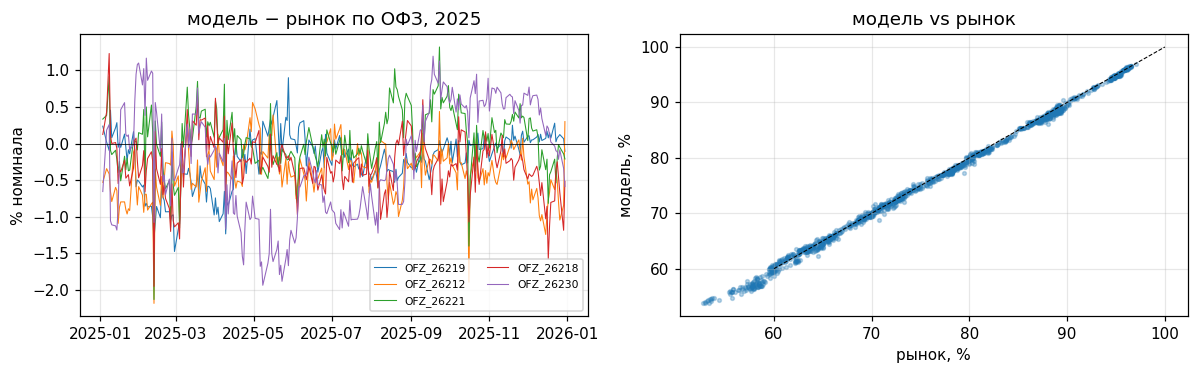

In [13]:
df_b, summ_b = P.validate_bonds(md, cf, '2025-01-01', '2025-12-30')
print('Метрики по выпускам (% от номинала):')
print(summ_b.round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ofz_id in P.OFZ_IDS:
    s = df_b[df_b['ofz'] == ofz_id]
    axes[0].plot(s['DATE'], s['err'], lw=0.7, label=ofz_id)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('модель − рынок по ОФЗ, 2025')
axes[0].set_ylabel('% номинала')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)
axes[1].plot([60, 100], [60, 100], 'k--', lw=0.7)
axes[1].scatter(df_b['market'], df_b['model'], s=6, alpha=0.3)
axes[1].set_xlabel('рынок, %')
axes[1].set_ylabel('модель, %')
axes[1].set_title('модель vs рынок')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Выводы:

* **MAE 0.31–0.66 % номинала**.
* **Системный отрицательный bias** (у 4 из 5 выпусков модель систематически выдаёт цену на 0.2–0.4% ниже рыночной) — это не ошибка расчётов, а особенность рынка. Бескупонная кривая ЦБ строится по всем облигациям в целом, а отдельные выпуски ОФЗ-ПД могут торговаться дороже. ZCYC строится по всему рынку.
* **Дисперсия ошибки (std 0.36–0.76 %)** отражает изменчивость спреда во времени.
* **Scatter ложится на диагональ** — нет структурного несовпадения модель/рынок, только спред.

## 4. Pricing акций и валют + валидация

$P_t = P_{t_0}\cdot\exp(\sum_s r_s)$.

In [14]:
eq, fx = P.validate_cumret(md, rf, '2025-01-01', '2025-12-30')
eq_no = eq[eq['id'] != 'GMKN']
print(f'акции MAE без GMKN: {float(np.mean(np.abs(eq_no.err))):.6f} руб')
print(f'валюты MAE:          {float(np.mean(np.abs(fx.err))):.6f} руб')
print(f'GMKN  MAE:           {float(np.mean(np.abs(eq[eq.id=="GMKN"].err))):,.1f} руб')

акции MAE без GMKN: 0.000000 руб
валюты MAE:          0.000000 руб
GMKN  MAE:           12,119.5 руб


### Выводы: безмодельный контроль; нюанс GMKN

* `MAE = 0` для 9 из 10 акций и обеих валют — безмодельный pricing точен, пайплайн корректен (уровни согласованы со своими лог-доходностями). Это контроль, а не модель: цена тождественно восстанавливается из накопленной суммы `Σr`.
* У GMKN `MAE ≈ 12 120 руб`: reconstructed цена ≈ 14 946 руб против рыночной ≈ 149.5 руб — разница в ~100 раз, но это **рассогласование данных, а не баг pricing**. Блок 2 back-adjust'нул фактор `r_GMKN` (сплит «Норникеля» ≈100:1 от 08.04.2024 вырезан, реальное движение дня +1.6 % сохранено — оговорка 1 в README), а котировка `STK_GMKN` в `data_clean.csv` осталась на постсплит-шкале (`15 054 → 153 руб`). `validate_cumret` собирает цену как `база(до сплита)·exp(adjusted Σr)` — она идёт по досплит-шкале и не сходится с постсплит-котировкой.
* Для pricing по факторам это нейтрально: в Monte-Carlo блока 5 факторы и цены живут на одной шкале. Лечится за рамками базового конвейера — перевести `STK_GMKN` на шкалу `r_GMKN` (сплит-Adjusted ряд `CLOSE`).

## 5. Факторная модель акций через STOCK_PC1-3

Опциональная модель OLS по истории позволяет моделировать 10 акций через 3 фактора вместо 10 — снижение размерности Monte-Carlo. Но компромисс: жертвуем точностью ради скорости.

Факторная модель (3 PC) vs рынок, 2025:
тикер    R²  MAE цены, %  resid_std
 SBER 0.730         6.87     0.0124
 GAZP 0.605         5.39     0.0168
 LKOH 0.720         3.63     0.0107
 GMKN 0.796     11406.38     0.0091
 ROSN 0.806         3.72     0.0105
 NVTK 0.714         6.13     0.0131
 TATN 0.760         5.20     0.0114
 MGNT 0.649        11.68     0.0133
 MTSS 0.895         9.27     0.0068
 CHMF 0.791        17.37     0.0108


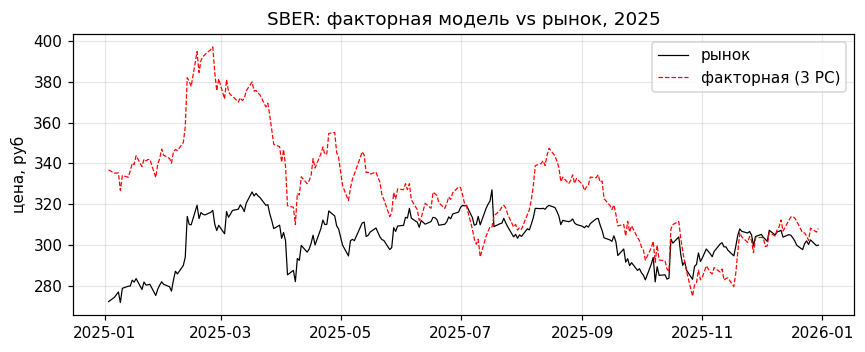

In [15]:
fit = P.equity_factor_fit(spca, rf)
vf = P.validate_equity_factor_model(spca, rf, md)
print('Факторная модель (3 PC) vs рынок, 2025:')
print(pd.DataFrame([{'тикер': tk, 'R²': round(fit[tk]['r2'], 3),
                     'MAE цены, %': round(vf[tk]['mae_pct'], 2),
                     'resid_std': round(fit[tk]['resid_std'], 4)}
                    for tk in P.STOCK_TICKERS]).to_string(index=False))

tk = 'SBER'
fac = P.equity_factor_returns(tk, spca, fit)
common = md.index.intersection(fac.index)
base = float(md[f'STK_{tk}'].asof(common[common < pd.Timestamp('2025-01-01')][-1]))
win = (common >= pd.Timestamp('2025-01-01')) & (common <= pd.Timestamp('2025-12-30'))
mdl = pd.Series(base * np.exp(fac.loc[common].cumsum().values), index=common).loc[win]
mkt = md.loc[common[win], f'STK_{tk}']
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(mkt.index, mkt.values, 'k-', lw=0.8, label='рынок')
ax.plot(mdl.index, mdl.values, 'r--', lw=0.8, label='факторная (3 PC)')
ax.set_title(f'{tk}: факторная модель vs рынок, 2025'); ax.legend()
ax.set_ylabel('цена, руб'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Выводы

- 3 главных компоненты объясняют **R² 0.61–0.90** (в среднем ≈0.73) изменчивости акций — 3 фактора заменяют 10 тикеров в Monte-Carlo ценой потери ~30 % дисперсии. Это осознанный компромисс «размерность ↔ точность».
- Оставшиеся ~30 % — специфический (idiosyncratic) риск каждой бумаги; его амплитуду задаёт `resid_std` из регрессии. Поэтому при симуляциях к факторной доходности нужно добавлять шум `N(0, resid_std)`, иначе VaR систематически занижен.
- `MAE цены %` по GMKN ≈ 11 400 % — **та же причина, что в §4** (рассогласование шкал: factor returns adjusted, market quote — нет). Сама регрессия обучена на чистом (adjusted) `r_GMKN`, её R² = 0.80 корректен; расходится только reconstructed цена с котировкой. По остальным 9 тикерам `MAE %` = 3.6–17.4 % — разумная точность факторного приближения.

## 6. Валютная позиция 

In [16]:
zero_usd = float((rf['r_USD'] == 0).mean())
zero_eur = float((rf['r_EUR'] == 0).mean())
print(f'доля нулевых приращений: USD {zero_usd*100:.1f}%, EUR {zero_eur*100:.1f}%')
print(f'но валюты в валидации дали MAE = 0.000000 руб — pricing «проглатывает» нули корректно')

доля нулевых приращений: USD 23.1%, EUR 23.1%
но валюты в валидации дали MAE = 0.000000 руб — pricing «проглатывает» нули корректно


### Выводы

* Для pricing нули нейтральны. Если курс не изменился, переоценка просто оставляет стоимость валютной позиции прежней.

## 7. Единая точка входа `price_instrument`

Диспетчер по `instrument['type']`.

In [17]:
rf_inst = {
    'date': asof, 'curve': curve, 'cashflows': cf,
    'base_prices': {'equity': {'SBER': float(md.loc[md.index[0], 'STK_SBER'])},
                    'fx':     {'USD': float(md.loc[md.index[0], 'FX_USD'])}},
    'equity_cumret': {'SBER': float(np.log(md.loc[asof, 'STK_SBER'] / md.loc[md.index[0], 'STK_SBER']))},
    'fx_cumret':     {'USD': float(np.log(md.loc[asof, 'FX_USD'] / md.loc[md.index[0], 'FX_USD']))},
}
for inst in [{'type': 'bond', 'id': 'OFZ_26219'},
             {'type': 'equity', 'id': 'SBER'},
             {'type': 'fx', 'id': 'USD'}]:
    print(f"  {inst['type']:7s} {inst['id']:9s}: {P.price_instrument(inst, rf_inst):.4f} руб")

  bond    OFZ_26219: 968.9392 руб
  equity  SBER     : 299.9000 руб
  fx      USD      : 77.4466 руб


## 8. Портфель и ежедневная ребалансировка 2025

Алгоритм (каждый день $t$): 

- по ценам $t{-}1$ определяем **количества** $n_i = w_i V_{t-1}/P_{i,t-1}$ (для валюты $n = \text{rub\_notional}/FX_{t-1}$)

- переоцениваем по ценам $t$: $V_t = \sum_i n_i P_{i,t}$.

**Спецификация портфеля:** 
- Облигации: 40% капитала, равномерно по 5 выпускам (по 8% каждый)

- Акции: 30% капитала, равномерно по 10 акциям (по 3% каждая)

- Валюта: по 100 млн рублей в USD и EUR (в сумме ≈30% капитала)

- Общий капитал: ≈666.67 млн рублей

сумма весов облигаций: 0.4
сумма весов акций:     0.3
рублёвый капитал:      666,666,667

торговых дней: 254
V_0 = 666,666,667  →  V_T = 665,898,676
Σ P&L = -767,991   std дневной доходности = 0.705%

средняя стоимость классов, млн руб:
bonds       266.7
equities    199.9
fx          199.8


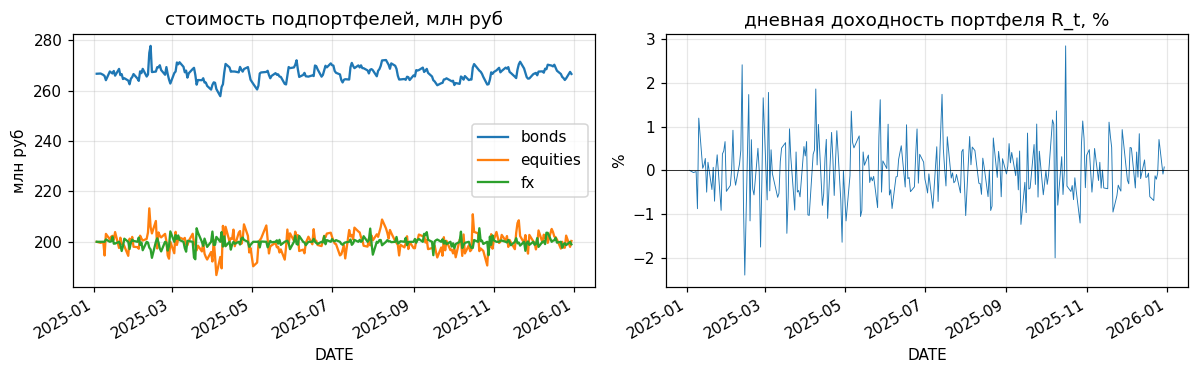

In [18]:
port = P.DEFAULT_PORTFOLIO
print('сумма весов облигаций:', round(sum(s['weight'] for s in port['bonds'].values()), 3))
print('сумма весов акций:    ', round(sum(s['weight'] for s in port['equities'].values()), 3))
print('рублёвый капитал:     ', f"{port['total_rub_capital']:,.0f}")
bt = P.backtest_portfolio(port, md, '2025-01-01', '2025-12-30')
print(f"\nторговых дней: {len(bt)}")
print(f"V_0 = {port['total_rub_capital']:,.0f}  →  V_T = {bt['value'].iloc[-1]:,.0f}")
print(f"Σ P&L = {bt['pnl'].sum():,.0f}   std дневной доходности = {bt['ret'].std()*100:.3f}%")
print('\nсредняя стоимость классов, млн руб:')
print((bt[['bonds', 'equities', 'fx']].mean() / 1e6).round(1).to_string())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
bt[['bonds', 'equities', 'fx']].div(1e6).plot(ax=axes[0])
axes[0].set_title('стоимость подпортфелей, млн руб')
axes[0].set_ylabel('млн руб')
axes[0].grid(alpha=0.3)
bt['ret'].mul(100).plot(ax=axes[1], lw=0.6)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('дневная доходность портфеля R_t, %')
axes[1].set_ylabel('%')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Выводы: ряд $R_t$ для блока 5; статичность расписания

* Процесс ребалансировки даёт ежедневные доходности портфеля.
* Стоимости классов стабильны во времени (bonds ≈266.7, equities ≈199.9, fx ≈199.8 млн руб.) — daily-rebalance удерживает целевые веса; дисперсия рядов и есть рыночный риск.
* Расписание платежей фиксировано. У обычных ОФЗ-ПД (без встроенных опционов) денежные потоки известны заранее — купоны и даты погашения. Поэтому переоценка при заданной кривой детерминирована: зная ставки, цена вычисляется однозначно.

## Итоги

| Блок | Результат | Критерий | Вывод |
|---|---|---|---|
| облигации | MAE **0.31–0.66 %** номинала | 0.5–2 % | ✅ в диапазоне |
| облигации | bias −0.20…−0.38 % (4 из 5) | — | спред ОФЗ-ПД к ZCYC, не баг |
| акции/валюты | MAE **0.0 руб** (без GMKN) | ≈ 0 | ✅ контроль конвейера |
| факторная модель | R² **0.6–0.9** (3 PC) | — | компромисс точность/размерность |
| ребалансировка | ряд $R_t$, 254 дня (253 шага) 2025 | — | ✅ для блока 5 |

### Точки расширения для блока 6 — «как добавить тип инструмента»

`pricing.py` спроектирован так, что блок 6 не переписывает ядро. Новый тип — 3 шага:
1. **Расширить диспетчер `price_instrument`** новым `instrument['type']`: `'option_future'` (Блэк-76), `'bond_callable'`/`'bond_puttable'` (биномиальное дерево/BDT).
2. **Добавить функцию `price_*`** с той же конвенцией (возвращает стоимость единицы, руб.).
3. **Описать зависимость от факторов:** Блэк-76 требует волатильность; биномиальное дерево облигаций требует кривую — использует `get_rate_curve(date, market_data)`.

### Контракт с блоком 5

```python
# кривая/цены из data_clean (валидация / backtesting):
curve = P.get_rate_curve(date, market_data=md)
clean, dirty, nkd = P.price_bond('OFZ_26219', date, curve, cf)   # % номинала
# ряд доходностей портфеля (ежедневная ребалансировка):
bt = P.backtest_portfolio(P.DEFAULT_PORTFOLIO, md, '2025-01-01', '2025-12-30')
# для Монте-Карло блок 5 сам переводит траектории факторов в абсолютные цены
# и передаёт их в price_portfolio через risk_factors['prices'].
```